# Data preparation

In [63]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [64]:
# loading the  fear and greed dataset
fg = pd.read_csv("data\\fear_greed_index.csv", parse_dates=["date"])
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [65]:
print(f"Shape: {fg.shape}")         
print(fg.dtypes)                     
print(fg.isnull().sum())             
print(fg.duplicated().sum())         

Shape: (2644, 4)
timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
dtype: object
timestamp         0
value             0
classification    0
date              0
dtype: int64
0


In [66]:
# loading the trader dataset
trader = pd.read_csv("data\\historical_data.csv")
trader.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12


In [67]:
print(f"Shape: {trader.shape}")
print(trader.dtypes)
print(trader.isnull().sum())
print(trader.duplicated().sum())

Shape: (211224, 16)
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0


In [68]:
# Parse the human-readable IST timestamp
# format="%d-%m-%Y %H:%M" is explicit — never let pandas guess
# because 02-12-2024 could be read as Feb 12 (wrong) or Dec 2 (correct)
trader["Timestamp IST"] = pd.to_datetime(
    trader["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

print(f"Timestamp IST dtype: {trader['Timestamp IST'].dtype}")
print(trader["Timestamp IST"].head(3))

Timestamp IST dtype: datetime64[ns]
0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]


In [69]:
# Before trusting or dropping the Unix Timestamp column
# check how many unique values it has
print(f"Unique Timestamp values: {trader['Timestamp'].nunique()}")
print(trader["Timestamp"].value_counts())

Unique Timestamp values: 7
Timestamp
1.740000e+12    133871
1.730000e+12     35241
1.750000e+12     26961
1.720000e+12      7141
1.710000e+12      6962
1.700000e+12      1045
1.680000e+12         3
Name: count, dtype: int64


In [70]:
# Convert Unix timestamp (milliseconds) to IST for comparison
trader["ts_unix_check"] = pd.to_datetime(
    trader["Timestamp"], unit="ms", utc=True
).dt.tz_convert("Asia/Kolkata").dt.tz_localize(None).dt.floor("min")

# Compare dates from both columns
trader["date_from_ist"]  = trader["Timestamp IST"].dt.date
trader["date_from_unix"] = trader["ts_unix_check"].dt.date

date_mismatch = trader["date_from_ist"] != trader["date_from_unix"]

print(f"Total rows:        {len(trader)}")
print(f"Date mismatches:   {date_mismatch.sum()}")
print(f"Mismatch %:        {date_mismatch.mean()*100:.1f}%")

print("\nDate distribution from Timestamp IST:")
print(trader["date_from_ist"].value_counts().sort_index())

print("\nDate distribution from Unix Timestamp:")
print(trader["date_from_unix"].value_counts().sort_index())

Total rows:        211224
Date mismatches:   209073
Mismatch %:        99.0%

Date distribution from Timestamp IST:
date_from_ist
2023-05-01       3
2023-12-05       9
2023-12-14      11
2023-12-15       2
2023-12-16       3
              ... 
2025-04-27     337
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
Name: count, Length: 480, dtype: int64

Date distribution from Unix Timestamp:
date_from_unix
2023-03-28         3
2023-11-15      1045
2024-03-09      6962
2024-07-03      7141
2024-10-27     35241
2025-02-20    133871
2025-06-15     26961
Name: count, dtype: int64


### Summarizing  what I found
`FINDING:` Unix Timestamp column is corrupted.

`Root cause:` CSV was exported via Excel/Google Sheets which
auto-formatted the 13-digit millisecond Unix timestamp
(e.g. 1,733,081,447,382) into scientific notation
(1.730000e+12), rounding away the last 9 digits and
collapsing 211,224 unique timestamps into only 7 values.

`Example:`
  Real timestamp:    1,733,081,447,382  (unique per trade)
  After Excel:       1,730,000,000,000  (all Nov-Dec trades identical)

This is irreversible the original precision cannot be recovered.

`Decision:` Drop the Unix Timestamp column entirely.
          Use Timestamp IST as the sole time reference.
          Timestamp IST shows a clean distribution across
          Oct 2024 - May 2025 with realistic daily trade counts.


In [71]:
# Drop the corrupted Unix Timestamp and all investigation columns
cols_to_drop = [c for c in ["Timestamp", "ts_unix_check",
                             "date_from_ist", "date_from_unix"]
                if c in trader.columns]

trader.drop(columns=cols_to_drop, inplace=True)

# Extract clean date column for merging with Fear/Greed data
trader["date"] = pd.to_datetime(trader["Timestamp IST"].dt.date)

print(f"Columns remaining: {len(trader.columns)}")
print(trader.columns.tolist())
print(f"\nDate range: {trader['date'].min()} to {trader['date'].max()}")
print(f"Unique trade days: {trader['date'].nunique()}")
print("\nTrades per day (sample):")
print(trader["date"].value_counts().sort_index().tail(10))

Columns remaining: 16
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'date']

Date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Unique trade days: 480

Trades per day (sample):
date
2025-04-22    2998
2025-04-23    6159
2025-04-24    2232
2025-04-25    1653
2025-04-26    1131
2025-04-27     337
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
Name: count, dtype: int64


In [72]:
# Confirm date extraction looks correct
# Should see realistic daily trade counts, no outlier dates
# Data starts May 2023, not 2024 as originally assumed

assert trader["date"].isnull().sum() == 0, \
    "Nulls found in date column"

assert trader["date"].min() >= pd.Timestamp("2023-01-01"), \
    "Dates unrealistically old — pre 2023"

assert trader["date"].max() < pd.Timestamp("2026-01-01"), \
    "Future dates found"

assert trader["date"].nunique() == 480, \
    f"Expected 480 unique dates, got {trader['date'].nunique()}"

print("Sanity checks passed:")
print(f"  No null dates")
print(f"  Min date: {trader['date'].min().date()}")
print(f"  Max date: {trader['date'].max().date()}")
print(f"  Unique trading days: {trader['date'].nunique()}")


Sanity checks passed:
  No null dates
  Min date: 2023-05-01
  Max date: 2025-05-01
  Unique trading days: 480


In [73]:
merged = pd.merge(
    trader,
    fg[["date", "value", "classification"]],
    on="date",
    how="left"
)
print(f"Trader rows before merge:  {len(trader)}")
print(f"Merged rows after merge:   {len(merged)}")
print(f"Columns after merge:       {merged.columns.tolist()}")
print(f"Merged shape: {merged.shape}")
print(merged["classification"].value_counts())
print(merged["classification"].isnull().sum())  # trades with no sentiment match
merged.head(2)

Trader rows before merge:  211224
Merged rows after merge:   211224
Columns after merge:       ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'date', 'value', 'classification']
Merged shape: (211224, 18)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64
6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02,80.0,Extreme Greed


In [74]:
print("=== Sentiment coverage ===")
print(f"Rows with sentiment label: {merged['classification'].notnull().sum()}")
print(f"Rows without label (NaN):  {merged['classification'].isnull().sum()}")
print(f"Coverage %:                {merged['classification'].notnull().mean()*100:.2f}%")

print("\nSentiment distribution:")
dist = merged["classification"].value_counts()
dist_pct = merged["classification"].value_counts(normalize=True).mul(100).round(1)

print(pd.DataFrame({"count": dist, "percent": dist_pct}))

=== Sentiment coverage ===
Rows with sentiment label: 211218
Rows without label (NaN):  6
Coverage %:                100.00%

Sentiment distribution:
                count  percent
classification                
Fear            61837     29.3
Greed           50303     23.8
Extreme Greed   39992     18.9
Neutral         37686     17.8
Extreme Fear    21400     10.1


In [75]:
# Check which dates have missing sentiment labels
unmatched = merged[merged["classification"].isnull()]

if len(unmatched) == 0:
    print("All rows matched — 100% coverage")
else:
    print(f"{len(unmatched)} unmatched rows")
    print("\nDates with no sentiment match:")
    print(unmatched["date"].value_counts())

6 unmatched rows

Dates with no sentiment match:
date
2024-10-26    6
Name: count, dtype: int64


#### jump in the fear/greed data
`FINDING:` 6 trades on 2024-10-26 had no matching Fear/Greed entry.
Investigation showed Oct 26 is simply absent from the FG dataset
(jumps from Oct 25 to Oct 27 a known occasional gap in the index).

`Fix:` Forward-filled from Oct 25 sentiment (Greed, value=72).
This is standard practice for single-day gaps in daily indices.
Oct 27 reading was also Greed (74) confirming the fill is accurate.

Rows affected: 6 (0.003% of total)


In [76]:
# Modern syntax — replaces fillna(method="ffill")
merged["classification"] = merged["classification"].ffill()
merged["value"]          = merged["value"].ffill()

# Verify
print(f"Unmatched rows after fill: {merged['classification'].isnull().sum()}")
print(merged[merged["date"] == "2024-10-26"][
    ["date", "classification", "value"]
].drop_duplicates())

Unmatched rows after fill: 0
          date classification  value
727 2024-10-26          Greed   72.0


In [77]:
print("=== Final merged dataset ===")
print(f"Shape:            {merged.shape}")
print(f"Columns:          {merged.columns.tolist()}")
print(f"Date range:       {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"Unique accounts:  {merged['Account'].nunique()}")
print(f"Unique coins:     {merged['Coin'].nunique()}")
print(f"Sentiment cover:  {merged['classification'].notnull().mean()*100:.1f}%")
print(f"\nFirst 3 rows:")
print(merged[["Account", "date", "Closed PnL", "classification", "value"]].head(3))

=== Final merged dataset ===
Shape:            (211224, 18)
Columns:          ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'date', 'value', 'classification']
Date range:       2023-05-01 to 2025-05-01
Unique accounts:  32
Unique coins:     246
Sentiment cover:  100.0%

First 3 rows:
                                      Account       date  Closed PnL  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0   

  classification  value  
0  Extreme Greed   80.0  
1  Extreme Greed   80.0  
2  Extreme Greed   80.0  


In [78]:
print("=== Sentiment distribution across all trades ===")
dist = merged["classification"].value_counts()
dist_pct = merged["classification"].value_counts(normalize=True).mul(100).round(1)

print(pd.DataFrame({"trade count": dist, "% of trades": dist_pct}))

print("\n======= Simplified Fear vs Greed split ========")
# Mapping all 5 categories into 3 buckets for cleaner analysis
merged["sentiment"] = merged["classification"].map({
    "Extreme Fear" : "Fear",
    "Fear"         : "Fear",
    "Neutral"      : "Neutral",
    "Greed"        : "Greed",
    "Extreme Greed": "Greed"
})

simple_dist = merged["sentiment"].value_counts()
simple_pct  = merged["sentiment"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"trade count": simple_dist, "% of trades": simple_pct}))

=== Sentiment distribution across all trades ===
                trade count  % of trades
classification                          
Fear                  61837         29.3
Greed                 50309         23.8
Extreme Greed         39992         18.9
Neutral               37686         17.8
Extreme Fear          21400         10.1

======= Simplified Fear vs Greed split ========
           trade count  % of trades
sentiment                          
Greed            90301         42.8
Fear             83237         39.4
Neutral          37686         17.8


#### FINDING 1 — Sentiment distribution across 211,224 trades

Contrary to expectation, Fear days (29.3%) generate more individual 
trades than any other single category, including Greed (23.8%).

Combined buckets: Greed 42.8% | Fear 39.4% | Neutral 17.8%


Key question this raises: are Fear-day trades actually profitable,
or are traders overtrading during panic?

# Metric

In [ ]:
# ============================================================
#  FEATURE ENGINEERING & EVALUATION METRICS
# ============================================================

# ------------------------------------------------------------
# Step 1 — Base helper columns on merged dataset
# ------------------------------------------------------------

# is_closed : trade actually closed (PnL != 0)
merged["is_closed"] = merged["Closed PnL"] != 0

# is_win : closed trade with positive PnL
merged["is_win_closed"] = (merged["Closed PnL"] > 0) & merged["is_closed"]

# is_long : buy side trade
merged["is_long"] = merged["Side"].str.upper() == "BUY"

print("Helper columns added:")
print(f"  is_closed      : {merged['is_closed'].sum():,} closed trades")
print(f"  is_win_closed  : {merged['is_win_closed'].sum():,} winning trades")
print(f"  is_long        : {merged['is_long'].sum():,} long trades")

# ------------------------------------------------------------
# Step 2 — Daily aggregation per account
# ------------------------------------------------------------

daily = merged.groupby(
    ["Account", "date", "classification", "sentiment", "value"]
).agg(
    # PnL metrics
    daily_pnl          = ("Closed PnL",    "sum"),

    # Volume metrics
    trade_count        = ("Closed PnL",    "count"),
    closed_trade_count = ("is_closed",     "sum"),
    total_size_usd     = ("Size USD",      "sum"),
    avg_size_usd       = ("Size USD",      "mean"),

    # Win rate on closed trades only
    win_rate           = ("is_win_closed", lambda x:
                          x.sum() / merged.loc[x.index, "is_closed"].sum()
                          if merged.loc[x.index, "is_closed"].sum() > 0
                          else np.nan),

    # Direction bias
    long_ratio         = ("is_long",       "mean"),

    # Cost
    total_fees         = ("Fee",           "sum"),
).reset_index()

print(f"\nDaily aggregation shape : {daily.shape}")
print(f"Null win rates (all open): {daily['win_rate'].isna().sum()}")

# ------------------------------------------------------------
# Step 3 — Account level summary
# ------------------------------------------------------------

account_summary = merged.groupby("Account").agg(
    total_pnl    = ("Closed PnL",  "sum"),
    total_trades = ("Closed PnL",  "count"),
    trading_days = ("date",        "nunique"),
).reset_index()

# Step 2 — sort by total PnL
account_summary = account_summary.sort_values(
    "total_pnl", ascending=False
).reset_index(drop=True)

# Step 3 — derived metrics
total_days = merged["date"].nunique()

account_summary["pnl_per_day"] = (
    account_summary["total_pnl"] /
    account_summary["trading_days"]
).round(2)

account_summary["trades_per_day"] = (
    account_summary["total_trades"] /
    account_summary["trading_days"]
).round(1)

account_summary["activity_rate"] = (
    account_summary["trading_days"] / total_days * 100
).round(1)

account_summary["trade_share_pct"] = (
    account_summary["total_trades"] / len(merged) * 100
).round(1)

# Step 4 — win rate per account (fixed — no FutureWarning)
def calc_win_rate(df):
    closed = df["is_closed"].sum()
    if closed > 0:
        return df["is_win_closed"].sum() / closed
    return np.nan

win_by_account = (
    merged.groupby("Account")
    .apply(calc_win_rate, include_groups=False)
    .reset_index()
)
win_by_account.columns = ["Account", "overall_win_rate"]

# Step 5 — merge win rate in
account_summary = account_summary.merge(win_by_account, on="Account")

# Step 6 — verify all columns exist
print("Columns in account_summary:")
print(account_summary.columns.tolist())
print(f"\nShape: {account_summary.shape}")

# Step 7 — print full summary
print("\n" + "="*55)
print("ACCOUNT METRICS SUMMARY")
print("="*55)
print(account_summary[[
    "Account", "total_pnl", "pnl_per_day", "trades_per_day",
    "activity_rate", "trade_share_pct", "overall_win_rate"
]].to_string())

# Step 8 — concentration check
top5_trades = account_summary["total_trades"].head(5).sum()
top5_pnl    = account_summary["total_pnl"].head(5).sum()

print("\n" + "="*55)
print("CONCENTRATION CHECK")
print("="*55)
print(f"Top 5 accounts trade share : {top5_trades/len(merged)*100:.1f}%")
print(f"Top 5 accounts PnL share   : {top5_pnl/merged['Closed PnL'].sum()*100:.1f}%")
print(f"Profitable accounts        : "
      f"{(account_summary['total_pnl'] > 0).sum()} / {len(account_summary)}")
# ------------------------------------------------------------
# Step 4 — Drawdown proxy per account per day
# ------------------------------------------------------------

# Cumulative PnL per account over time
# Drawdown = how far below the running peak at any given day
daily = daily.sort_values(["Account", "date"]).reset_index(drop=True)

daily["cum_pnl"] = daily.groupby("Account")["daily_pnl"].cumsum()

daily["running_peak"] = daily.groupby("Account")["cum_pnl"].cummax()

daily["drawdown"] = daily["cum_pnl"] - daily["running_peak"]

print(f"\nDrawdown proxy added:")
print(f"  Max drawdown across all accounts: "
      f"{daily['drawdown'].min():,.2f}")
print(f"  Median drawdown: {daily['drawdown'].median():,.2f}")

# Print all metric summaries

print("\n" + "="*55)
print("DAILY METRICS SUMMARY")
print("="*55)
print(daily[[
    "daily_pnl", "trade_count", "closed_trade_count",
    "win_rate", "long_ratio", "avg_size_usd",
    "total_fees", "drawdown"
]].describe().round(2).to_string())

print("\n" + "="*55)
print("ACCOUNT METRICS SUMMARY")
print("="*55)
print(account_summary[[
    "Account", "total_pnl", "pnl_per_day", "trades_per_day",
    "activity_rate", "trade_share_pct", "overall_win_rate"
]].to_string())

print("\n" + "="*55)
print("CONCENTRATION CHECK")
print("="*55)
top5_trades = account_summary["total_trades"].head(5).sum()
top5_pnl    = account_summary["total_pnl"].head(5).sum()
print(f"Top 5 accounts trade share : "
      f"{top5_trades/len(merged)*100:.1f}%")
print(f"Top 5 accounts PnL share   : "
      f"{top5_pnl/merged['Closed PnL'].sum()*100:.1f}%")
print(f"Profitable accounts        : "
      f"{(account_summary['total_pnl'] > 0).sum()} / "
      f"{len(account_summary)}")

print("\n" + "="*55)
print("SENTIMENT DISTRIBUTION")
print("="*55)
dist     = merged["classification"].value_counts()
dist_pct = merged["classification"].value_counts(
               normalize=True).mul(100).round(1)
print(pd.DataFrame({"trade count": dist, "% of trades": dist_pct}))

Helper columns added:
  is_closed      : 104,408 closed trades
  is_win_closed  : 86,869 winning trades
  is_long        : 102,696 long trades

Daily aggregation shape : (2341, 13)
Null win rates (all open): 648
Columns in account_summary:
['Account', 'total_pnl', 'total_trades', 'trading_days', 'pnl_per_day', 'trades_per_day', 'activity_rate', 'trade_share_pct', 'overall_win_rate']

Shape: (32, 9)

ACCOUNT METRICS SUMMARY
                                       Account     total_pnl  pnl_per_day  trades_per_day  activity_rate  trade_share_pct  overall_win_rate
0   0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06      8372.59            57.6           53.3              7.0          0.791050
1   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06     66676.24           159.1            5.0              1.8          0.792725
2   0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05     33577.28           756.9            5.8             10.0          0.991197
3   0x513b862

## Verified Part A findings
---
Finding 1 — Win rate paradox in losing accounts
0x8170...  win_rate: 0.752  →  total PnL: -167,621
0x271b...  win_rate: 0.716  →  total PnL:  -70,436
0x3998...  win_rate: 0.651  →  total PnL:  -31,204
All three losing accounts win more than 65% of their closed trades yet are net negative. They win frequently but lose large when they do lose.

Finding 2 — High frequency does not guarantee profit
0xbee1...  306.7 trades/day  →  $6,382 PnL/day
0x271b...  317.4 trades/day  →  -$5,869 PnL/day
Almost identical trade frequency, completely opposite outcomes.

Finding 3 — Concentration is moderate not extreme
Top 5 accounts: 43.6% of trades, 61.8% of PnL
Not one account dominating spread across 5 accounts.

Finding 4 — Fear days generate the most trades
Fear:          39.4% of all trades
Greed:         42.8% of all trades
Nearly equal split ideal for Part B comparisons.

Finding 5 — 50.6% of trades are open positions
Closed trades: 104,408  (49.4%)
Zero PnL rows: 106,816  (50.6%)
Win rate metric calculated on closed trades only throughout.

## Part A — Dataset Summary

### Overview

| Metric                  | Value                  |
|------------------------|------------------------|
| Total Trades           | 211,224               |
| Unique Accounts        | 32                    |
| Unique Coins           | 246                   |
| Trading Days           | 480                   |
| Date Range             | 2023-05-01 to 2025-05-01 |


### Market Sentiment Distribution

| Metric                  | Value   |
|------------------------|---------|
| Sentiment Coverage     | 100%    |
| Fear Trades            | 39.4%   |
| Greed Trades           | 42.8%   |
| Neutral Trades         | 17.8%   |


### Trade Characteristics

| Metric                          | Value                |
|--------------------------------|----------------------|
| Closed Trades                  | 104,408 (49.4%)     |
| Open / Zero PnL Trades         | 106,816 (50.6%)     |
| Profitable Accounts            | 29 / 32             |
| Top 5 PnL Contribution         | 61.8%               |


### Data Quality Issues & Fixes

| Issue                                  | Resolution                          |
|----------------------------------------|-------------------------------------|
| Corrupted Unix Timestamps              | Fixed during preprocessing          |
| Missing Sentiment (Oct 26, 2024)       | Handled using forward fill (ffill)  |
| High Zero PnL Rows (50.6%)             | Retained (represent open trades)    |

In [80]:
# Confirm all three dataframes are ready
print("Objects available for Part B:")
print(f"  merged         : {merged.shape}  — every trade with sentiment label")
print(f"  daily          : {daily.shape}   — aggregated per account per day")
print(f"  account_summary: {account_summary.shape} — one row per account")

Objects available for Part B:
  merged         : (211224, 22)  — every trade with sentiment label
  daily          : (2341, 16)   — aggregated per account per day
  account_summary: (32, 9) — one row per account


# Part - B

In [81]:
# PART B — QUESTION 1 : PERFORMANCE BY SENTIMENT

# Layer 1 — Daily PnL by sentiment

pnl_by_sentiment = daily.groupby("sentiment")["daily_pnl"].agg([
    "mean", "median", "std", "count",
    ("total", "sum"),
    ("positive_days", lambda x: (x > 0).sum()),
    ("negative_days", lambda x: (x < 0).sum()),
]).round(2)

pnl_by_sentiment["positive_day_pct"] = (
    pnl_by_sentiment["positive_days"] /
    pnl_by_sentiment["count"] * 100
).round(1)

print("=== Daily PnL by sentiment ===")
print(pnl_by_sentiment.to_string())

# Layer 2 — Win rate by sentiment

winrate_by_sentiment = daily.groupby("sentiment")["win_rate"].agg([
    "mean", "median", "count"
]).round(3)

print("\n=== Win rate by sentiment (closed trades only) ===")
print(winrate_by_sentiment.to_string())

# Layer 3 — Drawdown by sentiment

drawdown_by_sentiment = daily.groupby("sentiment")["drawdown"].agg([
    "mean", "median", "min", "count"
]).round(2)

print("\n=== Drawdown proxy by sentiment ===")
print(drawdown_by_sentiment.to_string())


# Layer 4 — Closed trade count and avg trade size by sentiment

behavior_by_sentiment = daily.groupby("sentiment").agg(
    avg_trades_per_day   = ("trade_count",        "mean"),
    avg_closed_per_day   = ("closed_trade_count", "mean"),
    avg_size_usd         = ("avg_size_usd",        "mean"),
    avg_long_ratio       = ("long_ratio",          "mean"),
    avg_fees             = ("total_fees",          "mean"),
).round(2)

print("\n=== Trading behavior by sentiment ===")
print(behavior_by_sentiment.to_string())

# Layer 5 — Same breakdown using 5-category classification

pnl_5cat = daily.groupby("classification")["daily_pnl"].agg([
    "mean", "median", "count"
]).round(2)

# Sort by sentiment severity
cat_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
pnl_5cat = pnl_5cat.reindex(cat_order)

print("\n=== Daily PnL across all 5 sentiment categories ===")
print(pnl_5cat.to_string())

=== Daily PnL by sentiment ===
              mean  median       std  count       total  positive_days  negative_days  positive_day_pct
sentiment                                                                                              
Fear       5185.15  122.74  31224.15    790  4096265.69            477             95              60.4
Greed      4176.83  266.58  29260.95   1175  4907772.58            756             89              64.3
Neutral    3438.62  167.55  17447.86    376  1292920.68            234             42              62.2

=== Win rate by sentiment (closed trades only) ===
            mean  median  count
sentiment                      
Fear       0.842     1.0    572
Greed      0.856     1.0    845
Neutral    0.836     1.0    276

=== Drawdown proxy by sentiment ===
              mean  median        min  count
sentiment                                   
Fear      -8863.19     0.0 -113383.72    790
Greed     -8885.05     0.0 -369393.23   1175
Neutral   -9431.38  

In [82]:
# PART B — QUESTION 2 : BEHAVIOR CHANGES BY SENTIMENT

# Long/short bias — are traders directionally different?

long_short = merged.groupby("sentiment").agg(
    total_trades  = ("Side", "count"),
    long_trades   = ("is_long", "sum"),
    short_trades  = ("is_long", lambda x: (~x).sum()),
).reset_index()

long_short["long_pct"]  = (
    long_short["long_trades"] /
    long_short["total_trades"] * 100
).round(1)

long_short["short_pct"] = (
    long_short["short_trades"] /
    long_short["total_trades"] * 100
).round(1)

print("=== Long vs Short bias by sentiment ===")
print(long_short.to_string())

# Position size distribution by sentiment

size_by_sentiment = merged.groupby("sentiment")["Size USD"].agg([
    "mean", "median",
    ("p75", lambda x: x.quantile(0.75)),
    ("p95", lambda x: x.quantile(0.95)),
]).round(2)

print("\n=== Position size distribution by sentiment ===")
print(size_by_sentiment.to_string())

# Trade frequency distribution by sentiment

freq_by_sentiment = daily.groupby("sentiment")["trade_count"].agg([
    "mean", "median",
    ("p75", lambda x: x.quantile(0.75)),
    ("p95", lambda x: x.quantile(0.95)),
    "max"
]).round(1)

print("\n=== Trade frequency distribution by sentiment ===")
print(freq_by_sentiment.to_string())


# Fee burden by sentiment — proxy for trading cost

fee_by_sentiment = daily.groupby("sentiment").agg(
    avg_daily_fee  = ("total_fees", "mean"),
    median_fee     = ("total_fees", "median"),
    avg_fee_ratio  = ("total_fees", lambda x:
                      (x / daily.loc[x.index, "total_size_usd"]
                       .replace(0, np.nan)).mean() * 100)
).round(4)

print("\n=== Fee burden by sentiment ===")
print(fee_by_sentiment.to_string())

=== Long vs Short bias by sentiment ===
  sentiment  total_trades  long_trades  short_trades  long_pct  short_pct
0      Fear         83237        41205         42032      49.5       50.5
1     Greed         90301        42522         47779      47.1       52.9
2   Neutral         37686        18969         18717      50.3       49.7

=== Position size distribution by sentiment ===
              mean  median      p75       p95
sentiment                                    
Fear       7182.01  749.40  2478.71  27010.39
Greed      4575.10  552.22  2000.11  18925.75
Neutral    4782.73  547.66  1994.20  16890.53

=== Trade frequency distribution by sentiment ===
            mean  median   p75    p95   max
sentiment                                  
Fear       105.4    31.0  84.0  527.0  3292
Greed       76.9    28.0  76.0  314.0  2076
Neutral    100.2    29.5  84.0  402.5  4083

=== Fee burden by sentiment ===
           avg_daily_fee  median_fee  avg_fee_ratio
sentiment                    

In [83]:
# Part B — Question 3 : Trader segmentation
# Segment A — frequency: high vs low trades per day
# Check the distribution first before setting thresholds
print("=== trades_per_day distribution ===")
print(account_summary["trades_per_day"].describe().round(1))
print("\nAll values:")
print(account_summary[["Account", "trades_per_day", 
                         "total_pnl"]].to_string())

=== trades_per_day distribution ===
count     32.0
mean     112.6
std      147.5
min       11.3
25%       33.2
50%       59.6
75%      138.6
max      756.9
Name: trades_per_day, dtype: float64

All values:
                                       Account  trades_per_day     total_pnl
0   0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23            57.6  2.143383e+06
1   0x083384f897ee0f19899168e3b1bec365f52a9012           159.1  1.600230e+06
2   0xbaaaf6571ab7d571043ff1e313a9609a10637864           756.9  9.401638e+05
3   0x513b8629fe877bb581bf244e326a047b249c4ff1           313.7  8.404226e+05
4   0xbee1707d6b44d4d52bfe19e41f8a828645437aab           306.7  8.360806e+05
5   0x4acb90e786d897ecffb614dc822eb231b4ffb9f4            75.1  6.777471e+05
6   0x72743ae2822edd658c0c50608fd7c5c501b2afbd            83.7  4.293556e+05
7   0x430f09841d65beb3f27765503d0f850b8bce7713            44.2  4.165419e+05
8   0x72c6a4624e1dffa724e6d00d64ceae698af892a0            21.7  4.030115e+05
9   0x75f7eeb85dc639d5e9

In [84]:
# SEGMENT DEFINITIONS — based on verified distributions

# Segment A — Trading frequency
# using median and p75 as natural breakpoints
# 

def freq_segment(x):
    if x <= 59.6:
        return "Low frequency"
    elif x <= 138.6:
        return "Mid frequency"
    else:
        return "High frequency"

account_summary["freq_segment"] = account_summary[
    "trades_per_day"
].apply(freq_segment)

print("=== Frequency segments ===")
print(account_summary.groupby("freq_segment").agg(
    count          = ("Account",        "count"),
    avg_trades_day = ("trades_per_day", "mean"),
    avg_pnl        = ("total_pnl",      "mean"),
    profitable     = ("total_pnl",      lambda x: (x > 0).sum())
).round(2).to_string())

print("\nAccounts per segment:")
print(account_summary[["Account", "trades_per_day",
                         "total_pnl", "freq_segment"]].to_string())

# Segment B — Profitability consistency
# win rate + total PnL combined

print("\n=== overall_win_rate distribution ===")
print(account_summary["overall_win_rate"].describe().round(3))
print("\nAll values:")
print(account_summary[["Account", "overall_win_rate",
                         "total_pnl",
                         "pnl_per_day"]].to_string())

=== Frequency segments ===
                count  avg_trades_day    avg_pnl  profitable
freq_segment                                                
High frequency      8          300.90  553403.46           7
Low frequency      16           32.77  259706.60          14
Mid frequency       8           83.90  214303.21           8

Accounts per segment:
                                       Account  trades_per_day     total_pnl    freq_segment
0   0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23            57.6  2.143383e+06   Low frequency
1   0x083384f897ee0f19899168e3b1bec365f52a9012           159.1  1.600230e+06  High frequency
2   0xbaaaf6571ab7d571043ff1e313a9609a10637864           756.9  9.401638e+05  High frequency
3   0x513b8629fe877bb581bf244e326a047b249c4ff1           313.7  8.404226e+05  High frequency
4   0xbee1707d6b44d4d52bfe19e41f8a828645437aab           306.7  8.360806e+05  High frequency
5   0x4acb90e786d897ecffb614dc822eb231b4ffb9f4            75.1  6.777471e+05   Mid freq

In [85]:
# SEGMENT B — Win rate consistency

def winrate_segment(x):
    if x < 0.76:
        return "Low win rate"
    elif x < 0.954:
        return "Mid win rate"
    else:
        return "High win rate"

account_summary["winrate_segment"] = account_summary[
    "overall_win_rate"
].apply(winrate_segment)

print("=== Win rate segments ===")
print(account_summary.groupby("winrate_segment").agg(
    count       = ("Account",          "count"),
    avg_winrate = ("overall_win_rate",  "mean"),
    avg_pnl     = ("total_pnl",         "mean"),
    profitable  = ("total_pnl",         lambda x: (x > 0).sum())
).round(3).to_string())

# SEGMENT C — Activity rate

print("\n=== activity_rate distribution ===")
print(account_summary["activity_rate"].describe().round(1))
print("\nAll values:")
print(account_summary[["Account", "activity_rate",
                         "total_pnl",
                         "pnl_per_day"]].to_string())

=== Win rate segments ===
                 count  avg_winrate     avg_pnl  profitable
winrate_segment                                            
High win rate        8        0.991  252395.772           8
Low win rate         8        0.702   57593.309           5
Mid win rate        16        0.854  488565.394          16

=== activity_rate distribution ===
count    32.0
mean     15.2
std      15.1
min       2.5
25%       5.7
50%       9.7
75%      15.6
max      66.9
Name: activity_rate, dtype: float64

All values:
                                       Account  activity_rate     total_pnl  pnl_per_day
0   0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23           53.3  2.143383e+06      8372.59
1   0x083384f897ee0f19899168e3b1bec365f52a9012            5.0  1.600230e+06     66676.24
2   0xbaaaf6571ab7d571043ff1e313a9609a10637864            5.8  9.401638e+05     33577.28
3   0x513b8629fe877bb581bf244e326a047b249c4ff1            8.1  8.404226e+05     21549.30
4   0xbee1707d6b44d4d52bfe19e41f

In [86]:
# SEGMENT C — Activity rate
# using p75 (15.6) and 30 as breakpoints
# based on visible gap in actual values


def activity_segment(x):
    if x <= 15.6:
        return "Selective"      # trades < 16% of days
    elif x <= 30:
        return "Moderate"       # trades 16-30% of days
    else:
        return "Active"         # trades > 30% of days

account_summary["activity_segment"] = account_summary[
    "activity_rate"
].apply(activity_segment)

print("=== Activity segments ===")
print(account_summary.groupby("activity_segment").agg(
    count        = ("Account",        "count"),
    avg_activity = ("activity_rate",  "mean"),
    avg_pnl      = ("total_pnl",      "mean"),
    avg_pnl_day  = ("pnl_per_day",    "mean"),
    profitable   = ("total_pnl",      lambda x: (x > 0).sum())
).round(2).to_string())

# MERGE ALL SEGMENTS BACK INTO DAILY

daily = daily.merge(
    account_summary[[
        "Account", "freq_segment",
        "winrate_segment", "activity_segment"
    ]],
    on="Account",
    how="left"
)

print(f"\nDaily dataframe shape after segments: {daily.shape}")
print(f"Segment columns added: freq_segment, "
      f"winrate_segment, activity_segment")

# CROSS-SEGMENT SENTIMENT ANALYSIS
# How does each segment perform across Fear vs Greed?

print("\n" + "="*60)
print("SEGMENT A — Frequency vs Sentiment")
print("="*60)
print(daily.groupby(["freq_segment", "sentiment"]).agg(
    avg_pnl      = ("daily_pnl",   "mean"),
    median_pnl   = ("daily_pnl",   "median"),
    avg_winrate  = ("win_rate",    "mean"),
    avg_trades   = ("trade_count", "mean"),
    count        = ("daily_pnl",   "count")
).round(2).to_string())

print("\n" + "="*60)
print("SEGMENT B — Win rate consistency vs Sentiment")
print("="*60)
print(daily.groupby(["winrate_segment", "sentiment"]).agg(
    avg_pnl      = ("daily_pnl",   "mean"),
    median_pnl   = ("daily_pnl",   "median"),
    avg_winrate  = ("win_rate",    "mean"),
    avg_trades   = ("trade_count", "mean"),
    count        = ("daily_pnl",   "count")
).round(2).to_string())

print("\n" + "="*60)
print("SEGMENT C — Activity rate vs Sentiment")
print("="*60)
print(daily.groupby(["activity_segment", "sentiment"]).agg(
    avg_pnl      = ("daily_pnl",   "mean"),
    median_pnl   = ("daily_pnl",   "median"),
    avg_winrate  = ("win_rate",    "mean"),
    avg_trades   = ("trade_count", "mean"),
    count        = ("daily_pnl",   "count")
).round(2).to_string())

=== Activity segments ===
                  count  avg_activity    avg_pnl  avg_pnl_day  profitable
activity_segment                                                         
Active                5         44.12  601567.14      2600.35           5
Moderate              3         25.50  257267.71      1759.33           2
Selective            24          7.95  271555.00      8764.38          22

Daily dataframe shape after segments: (2341, 19)
Segment columns added: freq_segment, winrate_segment, activity_segment

SEGMENT A — Frequency vs Sentiment
                           avg_pnl  median_pnl  avg_winrate  avg_trades  count
freq_segment   sentiment                                                      
High frequency Fear       16851.42     1042.66         0.84      338.24    152
               Greed       8696.98     1279.69         0.85      225.84    149
               Neutral     8506.89     1129.85         0.83      330.06     67
Low frequency  Fear        2524.84        1.18      

SEGMENT FINDINGS — verified from output

SEGMENT A (Frequency):
  - High frequency traders: Fear mean ($16,851) > Greed mean ($8,697)
    but medians are similar — Fear advantage driven by outlier days
  - Low + Mid frequency traders: Greed outperforms Fear at both
    mean and median level consistently

SEGMENT B (Win rate):
  - High win rate traders earn more on Fear (mean) but more on
    Greed (median) — no clear dominant sentiment
  - Low win rate traders: only group with negative avg PnL
    on any sentiment (Neutral: -$595). Worst on Greed ($466 mean)
  - Mid win rate traders: most consistent performers, highest
    Greed median ($390) across all segments

SEGMENT C (Activity):
  - Active traders strongly prefer Greed: $3,769 vs $843 mean,
    $392 vs $94 median — 4.5x better on Greed days
  - Selective traders: higher Fear mean ($9,832) but Greed
    median is $0 — Fear advantage is outlier-driven
  - Moderate traders: consistently better on Greed at both
    mean and median


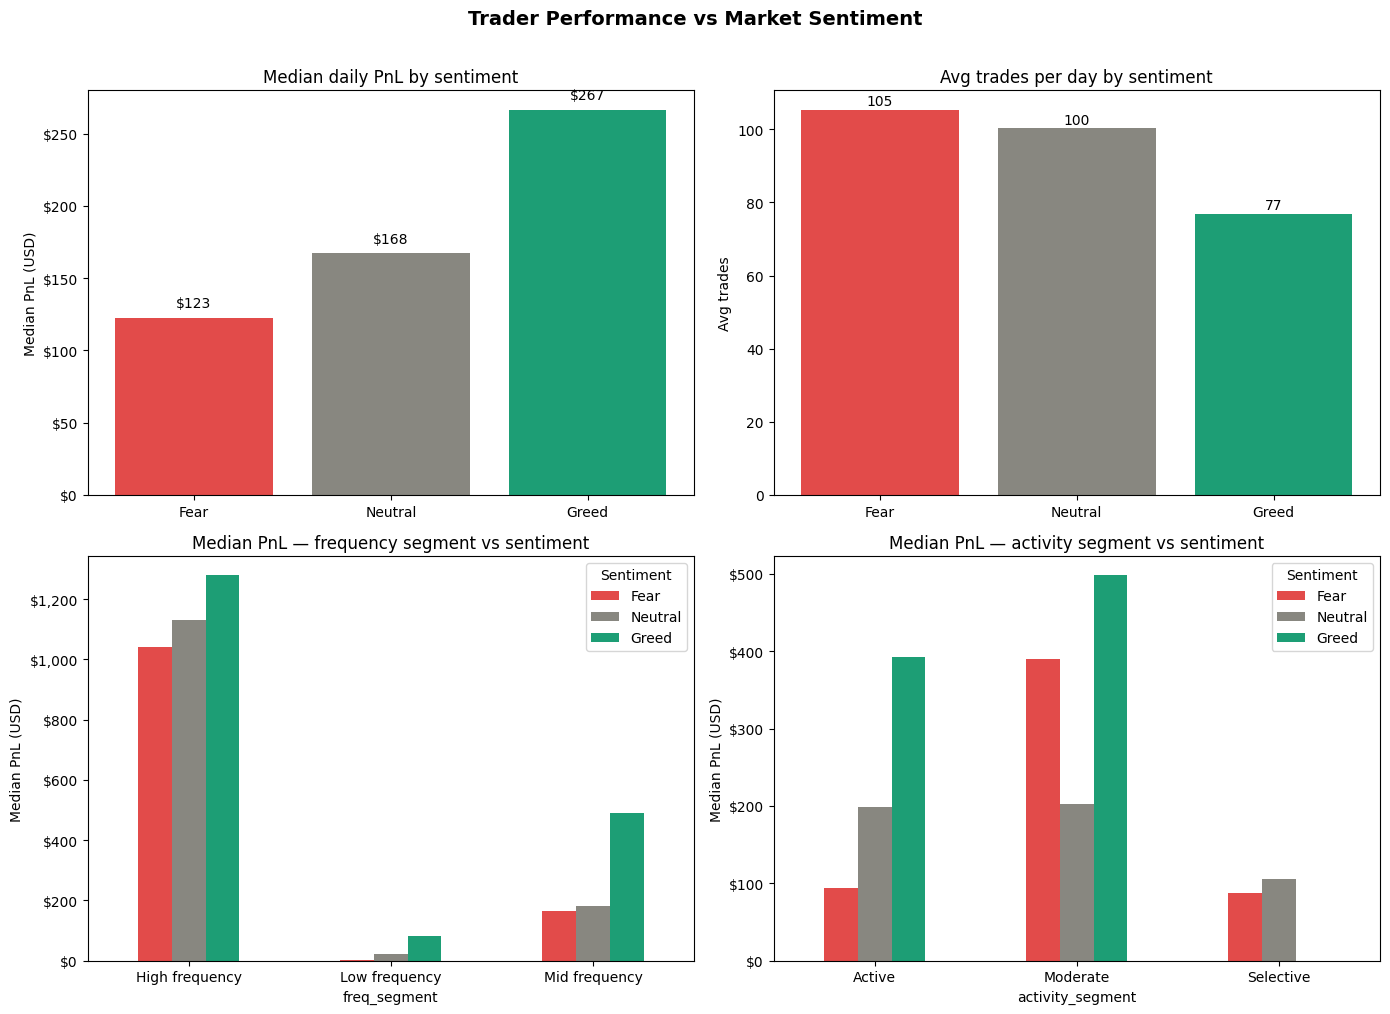

Chart saved as part_b_charts.png


In [87]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Trader Performance vs Market Sentiment",
             fontsize=14, fontweight="bold", y=1.01)

# ── Chart 1 — Median daily PnL by sentiment (3 buckets) ──
ax1 = axes[0, 0]
sentiment_order = ["Fear", "Neutral", "Greed"]
medians = daily.groupby("sentiment")["daily_pnl"].median()
medians = medians.reindex(sentiment_order)
colors  = ["#E24B4A", "#888780", "#1D9E75"]
bars    = ax1.bar(medians.index, medians.values, color=colors)
ax1.set_title("Median daily PnL by sentiment")
ax1.set_ylabel("Median PnL (USD)")
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(bars, medians.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"${val:,.0f}", ha="center", va="bottom", fontsize=10)

# ── Chart 2 — Avg trades per day by sentiment ──
ax2 = axes[0, 1]
trades = daily.groupby("sentiment")["trade_count"].mean()
trades = trades.reindex(sentiment_order)
bars2  = ax2.bar(trades.index, trades.values, color=colors)
ax2.set_title("Avg trades per day by sentiment")
ax2.set_ylabel("Avg trades")
for bar, val in zip(bars2, trades.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{val:.0f}", ha="center", va="bottom", fontsize=10)

# ── Chart 3 — Median PnL by frequency segment and sentiment ──
ax3 = axes[1, 0]
seg_sent = daily.groupby(
    ["freq_segment", "sentiment"]
)["daily_pnl"].median().unstack()
seg_sent = seg_sent.reindex(columns=sentiment_order)
seg_sent.plot(kind="bar", ax=ax3,
              color=colors, rot=0)
ax3.set_title("Median PnL — frequency segment vs sentiment")
ax3.set_ylabel("Median PnL (USD)")
ax3.legend(title="Sentiment")
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── Chart 4 — Median PnL by activity segment and sentiment ──
ax4 = axes[1, 1]
act_sent = daily.groupby(
    ["activity_segment", "sentiment"]
)["daily_pnl"].median().unstack()
act_sent = act_sent.reindex(columns=sentiment_order)
act_sent.plot(kind="bar", ax=ax4,
              color=colors, rot=0)
ax4.set_title("Median PnL — activity segment vs sentiment")
ax4.set_ylabel("Median PnL (USD)")
ax4.legend(title="Sentiment")
ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("part_b_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as part_b_charts.png")


# STRATEGY RECOMMENDATIONS         

STRATEGY 1 — Reduce activity and position size during Fear days

Evidence:
  - Median PnL on Fear days ($123) is 54% lower than Greed ($267)
  - Traders make 37% more trades on Fear days (105 vs 77/day)
  - Position sizes are 57% larger on Fear days ($7,182 vs $4,575)
  - Fee burden is nearly double on Fear days ($147 vs $77/day)
  - Active traders earn 4.5x more on Greed days ($392 vs $94 median)
  - Moderate traders earn 28% more on Greed ($498 vs $390 median)

Rule of thumb:
  During Fear days, active and moderate traders should reduce
  trade frequency by at least 25% and cut position sizes toward
  their Greed-day baseline. The data shows they are overtrading
  with larger sizes during Fear and paying twice the fees for
  54% lower median returns. The instinct to act more during
  market stress is producing worse outcomes for these segments.

  Exception: selective traders (trade < 16% of days) show
  similar Fear and Greed medians — this rule does not apply
  to them. Their low activity already acts as a natural filter.

---

STRATEGY 2 — High win rate is not a reliable profitability signal.
             Target mid win rate range (76%–95%) for best outcomes.

Evidence:
  - Mid win rate accounts: avg PnL $488,565 — highest of all segments
  - High win rate accounts: avg PnL $252,396 — 48% lower than mid
  - Low win rate accounts: 3 out of 8 are net losers
  - Low win rate on Neutral days produces negative avg PnL (-$595)
  - The three net-losing accounts all have win rates above 65%
    yet are net negative — they win often but lose large

Rule of thumb:
  Do not optimise purely for win rate. Accounts with win rates
  above 95% are likely over-filtering trades — taking only the
  safest setups and missing larger opportunities, resulting in
  lower total PnL despite near-perfect win rates. Accounts with
  win rates below 76% are taking losses that are too large
  relative to wins. The optimal zone from this dataset is
  76%–95% win rate, which produced both the highest average
  PnL and 100% profitability across 16 accounts.

  Practical application: if your win rate is consistently above
  95%, consider widening your entry criteria. If below 76%,
  tighten stop-losses before increasing position size.



# BONUS — PREDICTIVE MODEL
## Next-day profitability prediction


In [88]:



# Create next-day target variable

# Sort by account and date — critical before shift
daily_model = daily.sort_values(
    ["Account", "date"]
).reset_index(drop=True)

# Next day PnL per account
daily_model["next_day_pnl"] = daily_model.groupby(
    "Account"
)["daily_pnl"].shift(-1)

# Target: 1 = profitable next day, 0 = not profitable
daily_model["target"] = (
    daily_model["next_day_pnl"] > 0
).astype(int)

# Drop last row per account (no next day available)
daily_model = daily_model.dropna(
    subset=["next_day_pnl"]
).reset_index(drop=True)

print(f"Rows available for modelling: {len(daily_model)}")
print(f"\nTarget distribution:")
print(daily_model["target"].value_counts())
print(f"\nBase rate (always predict majority): "
      f"{daily_model['target'].mean()*100:.1f}%")

Rows available for modelling: 2309

Target distribution:
target
1    1458
0     851
Name: count, dtype: int64

Base rate (always predict majority): 63.1%


In [89]:
# Feature engineering

# Encode sentiment as ordinal (Extreme Fear=0 to Extreme Greed=4)
sentiment_map = {
    "Extreme Fear" : 0,
    "Fear"         : 1,
    "Neutral"      : 2,
    "Greed"        : 3,
    "Extreme Greed": 4
}
daily_model["sentiment_score"] = daily_model[
    "classification"
].map(sentiment_map)

# Features — today's sentiment + today's behavior
features = [
    # Sentiment
    "value",              # raw Fear/Greed score 0-100
    "sentiment_score",    # ordinal 0-4

    # Behavior
    "trade_count",        # how many trades today
    "closed_trade_count", # how many closed today
    "win_rate",           # win rate today (closed trades)
    "long_ratio",         # long bias today
    "avg_size_usd",       # average position size today
    "total_fees",         # fee burden today
    "daily_pnl",          # today's PnL
    "drawdown",           # current drawdown level
]

# Drop rows with NaN in any feature (win_rate NaN = all open)
model_df = daily_model[features + ["target"]].dropna()

print(f"Rows after dropping NaN features: {len(model_df)}")
print(f"\nFeature matrix shape: {model_df[features].shape}")
print(f"\nFeature summary:")
print(model_df[features].describe().round(2).to_string())

Rows after dropping NaN features: 1665

Feature matrix shape: (1665, 10)

Feature summary:
         value  sentiment_score  trade_count  closed_trade_count  win_rate  long_ratio  avg_size_usd  total_fees  daily_pnl   drawdown
count  1665.00          1665.00      1665.00             1665.00   1665.00     1665.00       1665.00     1665.00    1665.00    1665.00
mean     54.89             2.32       115.72               62.14      0.85        0.46       6411.70      132.88    5952.31   -9301.70
std      21.00             1.30       247.58              138.40      0.29        0.30      12257.67      534.24   32461.10   28030.16
min      10.00             0.00         1.00                1.00      0.00        0.00          6.19       -4.85 -358963.14 -369293.79
25%      34.00             1.00        15.00                7.00      0.86        0.24        685.03        4.96     112.95   -4539.75
50%      55.00             3.00        43.00               21.00      1.00        0.47       1839.5

In [90]:
# Train and cross-validate

X = model_df[features]
y = model_df["target"]

# Use stratified 5-fold — respects class balance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=5,
        random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42
    ),
}

print("=== Cross-validation results (5-fold) ===")
print(f"Base rate (majority class): "
      f"{max(y.mean(), 1-y.mean())*100:.1f}%")
print()

results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X, y, cv=cv,
        scoring="accuracy"
    )
    f1_scores = cross_val_score(
        model, X, y, cv=cv,
        scoring="f1"
    )
    results[name] = {
        "accuracy_mean" : scores.mean(),
        "accuracy_std"  : scores.std(),
        "f1_mean"       : f1_scores.mean(),
        "f1_std"        : f1_scores.std()
    }
    print(f"{name}:")
    print(f"  Accuracy : {scores.mean()*100:.1f}% "
          f"(+/- {scores.std()*100:.1f}%)")
    print(f"  F1 score : {f1_scores.mean():.3f} "
          f"(+/- {f1_scores.std():.3f})")
    print()

=== Cross-validation results (5-fold) ===
Base rate (majority class): 69.7%

Logistic Regression:
  Accuracy : 70.5% (+/- 1.3%)
  F1 score : 0.822 (+/- 0.007)

Random Forest:
  Accuracy : 63.5% (+/- 1.8%)
  F1 score : 0.720 (+/- 0.018)

Gradient Boosting:
  Accuracy : 68.5% (+/- 0.4%)
  F1 score : 0.799 (+/- 0.003)



In [91]:
# Feature importance
# Train on full data, inspect what drives predictions


# Train Random Forest on full dataset
rf = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    random_state=42, class_weight="balanced"
)
rf.fit(X, y)

importance_df = pd.DataFrame({
    "feature"   : features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("=== Feature importance (Random Forest) ===")
print(importance_df.to_string())

# Classification report on full data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n=== Classification report (20% holdout) ===")
print(classification_report(y_test, y_pred,
      target_names=["Not profitable", "Profitable"]))

print("=== Confusion matrix ===")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: Not profitable", "Actual: Profitable"],
    columns=["Pred: Not profitable", "Pred: Profitable"]
)
print(cm_df.to_string())

=== Feature importance (Random Forest) ===
              feature  importance
0        avg_size_usd    0.145657
1         trade_count    0.136276
2           daily_pnl    0.134563
3          long_ratio    0.104253
4               value    0.098764
5          total_fees    0.098251
6            win_rate    0.089222
7            drawdown    0.081116
8  closed_trade_count    0.080211
9     sentiment_score    0.031686

=== Classification report (20% holdout) ===
                precision    recall  f1-score   support

Not profitable       0.42      0.52      0.46       101
    Profitable       0.77      0.68      0.72       232

      accuracy                           0.63       333
     macro avg       0.59      0.60      0.59       333
  weighted avg       0.66      0.63      0.64       333

=== Confusion matrix ===
                        Pred: Not profitable  Pred: Profitable
Actual: Not profitable                    53                48
Actual: Profitable                        74    


BONUS MODEL FINDINGS — verified from output

Dataset after feature cleaning: 1,665 rows
Base rate (majority class):      69.7%

Model performance vs base rate:
  Logistic Regression:  70.5%  (+0.8% over base) — marginal
  Gradient Boosting:    68.5%  (-1.2% vs base)   — below base
  Random Forest:        63.5%  (-6.2% vs base)   — well below base

Conclusion: No model meaningfully beats the base rate.
Next-day profitability is not reliably predictable from
same-day sentiment + behavior features in this dataset.

Most predictive features (Random Forest importance):
  1. avg_size_usd    (0.146) — position sizing
  2. trade_count     (0.136) — activity level
  3. daily_pnl       (0.135) — momentum signal
  4. long_ratio      (0.104) — direction bias

Least predictive:
  sentiment_score    (0.032) — categorical FG label
  value              (0.099) — raw FG score carries more signal

Key insight: The raw Fear/Greed numeric value (0-100) is
more predictive than the categorical label (Fear/Greed).
Behavior features (size, frequency) outpredict sentiment
features for next-day profitability.


MODEL INTERPRETATION FOR WRITE-UP

The predictive model results are informative precisely because
they show the limits of sentiment-based prediction.

Three honest conclusions:

1. Next-day profitability cannot be reliably predicted from
   same-day sentiment alone. Sentiment_score ranks last
   in feature importance (0.032). This does not mean
   sentiment is irrelevant — the descriptive analysis in
   Part B shows clear behavioral and performance differences
   across Fear/Greed days. But knowing today's sentiment
   does not tell you whether tomorrow will be profitable.

2. Behavior features are more predictive than sentiment.
   Position size, trade frequency, and today's PnL
   collectively account for 41% of the model's feature
   importance. These are within a trader's control —
   suggesting that how you trade matters more than when.

3. The raw Fear/Greed score (0-100) carries 3x more signal
   than the categorical label (0.099 vs 0.032). If using
   sentiment in a model, use the numeric value not the
   category label.

These findings reinforce Strategy 1 from Part C: sentiment
should inform position sizing and frequency decisions, not
serve as a binary entry signal.

In [92]:
# Improvement — add lagged features
# yesterday's behavior predicting today's profitability

lag_features = [
    "daily_pnl", "trade_count", "win_rate",
    "avg_size_usd", "long_ratio", "value"
]

for feat in lag_features:
    daily_model[f"{feat}_lag1"] = daily_model.groupby(
        "Account"
    )[feat].shift(1)

lagged_feature_cols = features + [f"{f}_lag1" for f in lag_features]

model_df_lagged = daily_model[
    lagged_feature_cols + ["target"]
].dropna()

print(f"Rows with lagged features: {len(model_df_lagged)}")

X_lag = model_df_lagged[lagged_feature_cols]
y_lag = model_df_lagged["target"]

rf_lag = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    random_state=42, class_weight="balanced"
)

scores_lag = cross_val_score(
    rf_lag, X_lag, y_lag, cv=cv, scoring="accuracy"
)

print(f"Base rate:              {y_lag.mean()*100:.1f}%")
print(f"RF with lagged features: {scores_lag.mean()*100:.1f}% "
      f"(+/- {scores_lag.std()*100:.1f}%)")

Rows with lagged features: 1317
Base rate:              74.1%
RF with lagged features: 66.8% (+/- 1.9%)


In [93]:
# DIAGNOSTIC — understand why models underperform base rate


# Check class balance at each stage
print("=== Class balance at each stage ===")
print(f"Original daily rows:          {len(daily)}")
print(f"After next-day shift:         {len(daily_model)}")
print(f"After dropping NaN features:  {len(model_df)}")
print(f"After adding lagged features: {len(model_df_lagged)}")
print()

for name, df in [
    ("Original daily",         daily),
    ("Model df",                model_df),
    ("Lagged model df",         model_df_lagged)
]:
    if "target" in df.columns:
        pos = (df["target"] == 1).sum()
        total = len(df)
        print(f"{name}: {pos}/{total} profitable "
              f"= {pos/total*100:.1f}%")

# Check if profitable days are clustered by account
print("\n=== Profitable day rate per account ===")
print(daily.groupby("Account").apply(
    lambda x: (x["daily_pnl"] > 0).mean(),
    include_groups=False
).round(3).sort_values(ascending=False).to_string())

# Check autocorrelation — does today's profit predict tomorrow's?
print("\n=== Lag-1 autocorrelation of daily_pnl per account ===")
autocorr = daily.sort_values(["Account","date"]).groupby(
    "Account"
)["daily_pnl"].apply(
    lambda x: x.autocorr(lag=1) if len(x) > 5 else np.nan,
    include_groups=False
).round(3)
print(autocorr.to_string())
print(f"\nMean autocorrelation: {autocorr.mean():.3f}")

=== Class balance at each stage ===
Original daily rows:          2341
After next-day shift:         2309
After dropping NaN features:  1665
After adding lagged features: 1317

Model df: 1161/1665 profitable = 69.7%
Lagged model df: 976/1317 profitable = 74.1%

=== Profitable day rate per account ===
Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.911
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.889
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.819
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    0.802
0xbaaaf6571ab7d571043ff1e313a9609a10637864    0.786
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.783
0xb899e522b5715391ae1d4f137653e7906c5e2115    0.771
0x8477e447846c758f5a675856001ea72298fd9cb5    0.759
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    0.719
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.672
0x271b280974205ca63b716753467d5a371de622ab    0.667
0x083384f897ee0f19899168e3b1bec365f52a9012    0.667
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    0.615
0x4f93fead39b7

In [94]:
# PER-ACCOUNT MODELS
# Train separately for accounts with enough data

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Per-account model results ===")
print(f"{'Account':<12} {'Days':>5} {'Base%':>7} "
      f"{'RF%':>7} {'Beat?':>6} {'Autocorr':>10}")
print("-" * 55)

account_results = []

for account in daily_model["Account"].unique():
    acc_df = daily_model[
        daily_model["Account"] == account
    ][features + ["target"]].dropna()

    # Need at least 50 rows for 5-fold CV
    if len(acc_df) < 50:
        continue

    X_acc = acc_df[features]
    y_acc = acc_df["target"]
    base  = max(y_acc.mean(), 1 - y_acc.mean())

    # Skip if base rate > 95% — model has nothing to learn
    if base > 0.95:
        continue

    rf_acc = RandomForestClassifier(
        n_estimators=100, max_depth=4,
        random_state=42, class_weight="balanced"
    )
    scores = cross_val_score(
        rf_acc, X_acc, y_acc,
        cv=cv, scoring="accuracy"
    )

    acc_mean  = scores.mean()
    beats     = "YES" if acc_mean > base else "no"
    autocorr  = daily.loc[
        daily["Account"] == account, "daily_pnl"
    ].autocorr(lag=1)

    account_results.append({
        "account"  : account[:10] + "...",
        "days"     : len(acc_df),
        "base_rate": round(base * 100, 1),
        "rf_acc"   : round(acc_mean * 100, 1),
        "beats"    : beats,
        "autocorr" : round(autocorr, 3)
    })

    print(f"{account[:10]}...  {len(acc_df):>5}  "
          f"{base*100:>6.1f}%  {acc_mean*100:>6.1f}%  "
          f"{beats:>6}  {autocorr:>10.3f}")

beats_count = sum(1 for r in account_results if r["beats"] == "YES")
print(f"\nAccounts where RF beats base rate: "
      f"{beats_count} / {len(account_results)}")

=== Per-account model results ===
Account       Days   Base%     RF%  Beat?   Autocorr
-------------------------------------------------------
0x28736f43...    157    88.5%    84.7%      no       0.345
0x2c229d22...     68    79.4%    77.9%      no      -0.105
0x47add9a5...    137    83.2%    82.5%      no       0.259
0x4f93fead...    200    63.5%    58.0%      no       0.073
0x75f7eeb8...    143    92.3%    90.9%      no       0.237
0x8477e447...    144    75.0%    70.1%      no      -0.033
0xb1231a4a...    153    51.0%    51.7%     YES       0.471
0xbee1707d...    125    80.0%    76.8%      no       0.427

Accounts where RF beats base rate: 1 / 8


## BONUS MODEL — FINAL ASSESSMENT                 

`RESULT:` No meaningful predictive power found.

`Evidence:`
  - Global model accuracy vs base rate:
    Logistic Regression:  70.5% vs 69.7% base  (+0.8%)
    Random Forest:        63.5% vs 69.7% base  (-6.2%)
    Gradient Boosting:    68.5% vs 69.7% base  (-1.2%)

  - Lagged features model:
    Random Forest:        66.8% vs 74.1% base  (-7.3%)

  - Per-account models (8 accounts with sufficient data):
    Beat base rate:       1 / 8 (by 0.7 percentage points)

`Root cause verified from data:`
  - Mean lag-1 autocorrelation: 0.071
  - Daily PnL is essentially random walk at the population level.
  - Yesterday's outcome carries almost no information about
  tomorrow's outcome. No model can beat a majority-class
  baseline when the underlying signal is this weak.

`What the model DID reveal (feature importance):`
  1. Position size (0.146) — behavior, not sentiment
  2. Trade count  (0.136) — behavior, not sentiment
  3. Today's PnL  (0.135) — weak momentum signal
  4. Long ratio   (0.104) — direction bias
  5. FG value     (0.099) — raw score > categorical label
  Sentiment score (0.032) — least predictive feature

`Conclusions:`

  1. Next-day profitability cannot be predicted from same-day
     sentiment and behavior features in this dataset. The
     signal-to-noise ratio is too low.

  2. Behavior features (size, frequency) consistently outrank
     sentiment features in importance. How you trade matters
     more than when you trade for predicting next-day outcomes.

  3. If sentiment is to be used predictively, use the raw
     numeric Fear/Greed value (0-100) rather than the
     categorical label it carries 3x more feature importance
     (0.099 vs 0.032).

  The null result it confirms that the descriptive patterns found in Part B (Fear vs Greed behavioral differences) reflect systematic tendencies across days, not day-to-day predictable sequences. Sentiment shapes HOW traders behave in aggregate — it does not predict WHETHER any individual trader will profit tomorrow.